# Attribution Explorer — BioS birthday recall

Step through people, see what the model predicts, then trace the date-recall circuit with circuit-tracer on the trained `grid-L4-H6` CLT. Section 8 (**Feature Explorer**) sweeps the CLT features that fire when the model recalls a given birth **month** across many people.

**Run order:** cells 1–3 once (setup, people, **load model**). Then per person: set `PERSON_IDX` in cell 4, run **4** (prompt + prediction) → **5** (build) → **6** (chart), and view in **7** (server stays up across rebuilds). Section **8** is independent — it only needs cells 1–3.

> Kernel must be the `clts/.venv-ct` interpreter.

## 1 · Setup

In [39]:
import re
import sys
from pathlib import Path

# The notebook lives in clts/; run everything relative to the repo root.
REPO = Path.cwd()
if REPO.name == "clts":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from clts.storage import storage_root
from util.condensed_tokenizer import CondensedTokenizer

# ── Pick which trained CLT + base model to explore ─────────────────────────
# One registry entry per depth. Each maps the base model dir (under model/) to
# the CLT run slug living at  <storage>/clt_runs/<scan>/standalone/<slug>/final
# (storage_root() = clt_storage/ on Mac, the PSC results dir on the cluster).
# Change CHOICE and re-run cells 1–3 (set `model = None` first to force a reload).
CLT_CHOICES = {
    "L1": ("grid-L1-H6", "mult8_l05_lr0.0001_ep15_n50000"),
    "L2": ("grid-L2-H6", "mult32_l02_lr0.0001_ep15_n50000"),
    "L4": ("grid-L4-H6", "mult16_l02_lr0.0001_ep50_n10000"),
    "L8": ("grid-L8-H6", "mult32_l02_lr0.0001_ep15_n50000"),
}
CHOICE = "L1"                       # <-- "L1" / "L2" / "L4" / "L8"

SCAN_NAME, _SLUG = CLT_CHOICES[CHOICE]
MODEL_DIR = REPO / "model" / SCAN_NAME
CLT_DIR   = storage_root() / "clt_runs" / SCAN_NAME / "standalone" / _SLUG / "final"
DATA_DIR  = REPO / "data/bioS_N-Bd_final_grid"
DEVICE    = "cpu"

# All explored prompts accumulate in ONE shared dir, so the viewer's dropdown
# lists them together (graph-metadata.json is merged across builds).
GRAPH_DIR = storage_root() / "clt_graphs" / SCAN_NAME / "explore"

# Used to skip people whose name has out-of-vocab subwords (same check the
# CLI's default_birthday_prompt uses).
ct = CondensedTokenizer.from_remap_path(DATA_DIR / "old_to_new.json")

def name_in_vocab(name: str) -> bool:
    try:
        ct.encode(name)
        return True
    except KeyError:
        return False

print(f"CHOICE={CHOICE!r}  scan={SCAN_NAME}")
print("repo        :", REPO)
print("model dir   :", MODEL_DIR)
print("clt dir     :", CLT_DIR)
print("graph dir   :", GRAPH_DIR)
for _label, _p in [("MODEL_DIR", MODEL_DIR), ("CLT_DIR", CLT_DIR), ("DATA_DIR", DATA_DIR)]:
    assert _p.exists(), f"{_label} for CHOICE={CHOICE!r} not found: {_p}"

CHOICE='L1'  scan=grid-L1-H6
repo        : /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4
model dir   : /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/model/grid-L1-H6
clt dir     : /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/clt_runs/grid-L1-H6/standalone/mult8_l05_lr0.0001_ep15_n50000/final
graph dir   : /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/clt_graphs/grid-L1-H6/explore


## 2 · Load people

In [40]:
import pandas as pd

from util.bio_sampler import BioSampler

sampler = BioSampler(DATA_DIR / "people.json", fields=("birthday",))
print(f"{len(sampler.people):,} people loaded")
pd.DataFrame(sampler.people[:5])

50,000 people loaded


,id,first_name,middle_name,last_name,birthday,birthmonth,birthyear,birthcity,university,field,company1name,company1city
0,1,Gabriella,Ella,Rigby,18,February,1816,"Long Beach, CA",Oregon State University,Business Analytics,Hyatt,"Chicago, IL"
1,3,Nevaeh,Alice,Kay,10,June,1859,"Durham, NC","Texas A&M University, College Station",Technology Management,UnitedHealth Group,"Minnetonka, MN"
2,4,Logan,Colton,Doherty,17,July,1741,"Fresno, CA",Boston University,Engineering,General Motors,"Detroit, MI"
3,6,Cesar,Vincent,Kumar,22,February,1850,"Albuquerque, NM",Augusta University,Botany,NextEra Energy,"Juno Beach, FL"
4,9,Ashlyn,Nevaeh,Poole,22,November,1716,"Des Moines, IA",George Washington University,Business Analytics,Forever 21,"Los Angeles, CA"


## 3 · Load the replacement model

Loads the circuit-tracer replacement model (custom Llama + trained CLT) **once** and caches it in `model`. Reused for the per-person prediction (cell 4) and the Feature Explorer (section 8). Re-running is a no-op; set `model = None` and re-run to force a reload.

> First load takes ~10 s on CPU.

In [41]:
from clts.export_tokenizer import ensure_hf_tokenizer
from clts.load_replacement_model import load_replacement_model

# Load + cache in the kernel. The same `model` powers the prediction in cell 4
# and the feature sweep in section 8. Reloads automatically when CHOICE/SCAN_NAME
# changes (so switching layers "just works"); set `model = None` to force a reload.
if globals().get("model") is None or getattr(model, "scan", None) != SCAN_NAME:
    _hf_tok = ensure_hf_tokenizer(DATA_DIR)
    model = load_replacement_model(MODEL_DIR, CLT_DIR, _hf_tok, SCAN_NAME, device=DEVICE)
    print(f"loaded replacement model — n_layers={model.cfg.n_layers}, "
          f"d_model={model.cfg.d_model}, d_vocab={model.cfg.d_vocab}, "
          f"scan={getattr(model, 'scan', SCAN_NAME)!r}")
else:
    print(f"model already loaded for {SCAN_NAME} (set `model = None` and re-run to force reload)")

[tokenizer] cache hit: /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/hf_tokenizers/0518e632
Moving model to device:  cpu
loaded replacement model — n_layers=1, d_model=384, d_vocab=1836, scan='grid-L1-H6'


## Templates & prompt helpers  *(run once; lists the trained phrasings)*

The model was trained on a pool of birthday paraphrases. This cell **lists them** so you can copy a phrasing, and defines the prompt builder (the same one `inference_explorer.ipynb` uses) so the next cell can trace **any** wording — fill `{name}`, `{month}`, etc. from a real person with whatever middle text you like.

Placeholders: `{name} {first} {middle} {last} {month} {day} {year} {date} {city} {university} {field} {company} {company_city} {he_she}`. `{date}` is the full `"{month} {day}, {year}"` (the templates' `{birthday}`). A single leading space is added automatically.

In [42]:
# ── Prompt helpers + template browser (run once after the model loads) ──────
# Fill a template string from a person dict, then trace ANY phrasing you like.
# Placeholders for TEMPLATE (cell below):
#   {name} {first} {middle} {last} {month} {day} {year} {date}
#   {city} {university} {field} {company} {company_city} {he_she}
# {date} is the full "{month} {day}, {year}" — i.e. the training templates' {birthday}.
# A leading space is auto-added so prompts stay on the training distribution.
import importlib

import torch
from data.bio_text import FIELD_SPECS


def person_fields(person: dict) -> dict:
    return {
        "name":  f"{person['first_name']} {person['middle_name']} {person['last_name']}",
        "first": person["first_name"], "middle": person["middle_name"],
        "last":  person["last_name"],
        "month": person["birthmonth"], "day": person["birthday"],
        "year":  person["birthyear"],
        "date":  f"{person['birthmonth']} {person['birthday']}, {person['birthyear']}",
        "city":  person.get("birthcity", ""), "university": person.get("university", ""),
        "field": person.get("field", ""), "company": person.get("company1name", ""),
        "company_city": person.get("company1city", ""),
        "he_she": "He" if person["id"] % 2 == 0 else "She",
    }


def build_prompt(template: str, person: dict | None = None) -> str:
    """Fill `template` from `person` (verbatim if person is None). One leading space."""
    text = template.format_map(person_fields(person)) if person is not None else template
    return text if (text and text[0].isspace()) else " " + text


def expected_next_token(prompt, person, exposure_idx=0):
    """Ground-truth next token IF `prompt` is a clean prefix of the person's bio
    (template `exposure_idx`); else None — e.g. for off-distribution phrasings
    like '...the marvelous day of', where the target falls back to the top pred."""
    if person is None:
        return None
    full = sampler.render(person, exposure_idx)
    if not (full.startswith(prompt) and len(full) > len(prompt)):
        return None
    full_ids = model.tokenizer.encode(full, add_special_tokens=False)
    p_ids    = model.tokenizer.encode(prompt, add_special_tokens=False)
    if full_ids[:len(p_ids)] == p_ids and len(full_ids) > len(p_ids):
        return model.tokenizer.decode([full_ids[len(p_ids)]])
    return None


def resolve_expected(which, prompt, person):
    """Map the TARGET knob to a token string to rank / attribute toward:
      'auto'               -> infer from the ground-truth bio (None if off-distribution)
      'month'/'day'/'year' -> that field as a leading-space token
      None                 -> nothing
      any other string     -> used literally (e.g. ' August')."""
    if which is None:
        return None
    if which == "auto":
        return expected_next_token(prompt, person)
    fld = {"month": "birthmonth", "day": "birthday", "year": "birthyear"}.get(which)
    return f" {person[fld]}" if (fld and person is not None) else which


# NOTE the LEADING SPACE in the name checks below — the model saw every bio
# starting " <Name> ...", so without it the condensed tokenizer drops ~97% of
# people (50,000 -> 1,551). Same convention as inference_explorer.ipynb.
def people_in_month(month):
    """All in-vocab people born in `month` (e.g. 'August'), in dataset order."""
    return [p for p in sampler.people
            if p["birthmonth"] == month and name_in_vocab(f" {p['first_name']} {p['last_name']}")]


def pick_in_vocab_person(person_idx, month=None):
    """The person_idx-th in-vocab person (stable 0-based). With `month` set
    (e.g. 'August'), only people BORN IN THAT MONTH are counted, so PERSON_IDX
    walks that subset; month=None walks everyone."""
    pool = people_in_month(month) if month is not None else \
        [p for p in sampler.people if name_in_vocab(f" {p['first_name']} {p['last_name']}")]
    if person_idx >= len(pool):
        raise IndexError(f"PERSON_IDX={person_idx} past the last of {len(pool)} in-vocab people"
                         + (f" born in {month}" if month else ""))
    if month is not None:
        print(f"{len(pool)} in-vocab people born in {month}; picking #{person_idx}.")
    return pool[person_idx]


def run_prompt(person_idx=0, template="{name} was born on", target="auto",
               custom_prompt=None, n_continue=4, month=None, top_k=10):
    """Build the prompt (from `template` filled with the chosen person, or
    `custom_prompt` verbatim), run the model, print the top-k prediction +
    optional greedy continuation, and return (prompt, target, slug). `month`
    restricts person selection to people born that month (e.g. 'August')."""
    person = None if custom_prompt is not None else pick_in_vocab_person(person_idx, month)

    if custom_prompt is not None:
        prompt = build_prompt(custom_prompt, None)   # raw text, just guarantee leading space
        tgt = None
        print("Custom prompt:", repr(prompt))
    else:
        prompt = build_prompt(template, person)
        tgt = resolve_expected(target, prompt, person)
        full_name = f"{person['first_name']} {person['middle_name']} {person['last_name']}"
        print(f"Person #{person_idx}{f' (born {month})' if month else ''}: {full_name}")
        for k in ("birthmonth", "birthday", "birthyear", "birthcity", "university", "field"):
            if k in person:
                print(f"  {k:11s}: {person[k]}")

    slug = re.sub(r"[^a-z0-9]+", "-", prompt.lower()).strip("-")[:60] or "graph"
    print("\nPrompt to trace :", repr(prompt))
    print("Target token    :", repr(tgt))
    print("Slug            :", slug)

    # Run the model -> top-k next tokens, mark the target.
    tokens = model.ensure_tokenized(prompt)
    with torch.inference_mode():
        probs = model(tokens.unsqueeze(0))[0, -1].softmax(-1)

    target_id = None
    if tgt is not None:
        _ids = model.tokenizer.encode(tgt, add_special_tokens=False)
        target_id = _ids[0] if len(_ids) == 1 else None

    top_p, top_i = probs.topk(top_k)
    print(f"\nModel prediction — top {top_k} next tokens:")
    for rank, (pi, pp) in enumerate(zip(top_i.tolist(), top_p.tolist()), 1):
        mark = "  <- target" if (target_id is not None and pi == target_id) else ""
        print(f"  {rank:>2}. {model.tokenizer.decode([pi])!r:<14} p={pp:.3f}{mark}")

    # No target (custom / off-distribution) -> default to top prediction so the
    # graph build has something to attribute toward.
    if tgt is None:
        tgt = model.tokenizer.decode([int(top_i[0])])
        print(f"\nNo target set — defaulting to top prediction {tgt!r}")
    elif target_id is not None:
        tgt_rank = int((probs > probs[target_id]).sum()) + 1
        print(f"\nTarget {tgt!r}: p={probs[target_id]:.3f}, rank {tgt_rank}/{probs.numel()}")
    else:
        print(f"\nTarget {tgt!r} is not a single token; left as-is for attribution.")

    if n_continue > 0:
        out = tokens.clone()
        with torch.inference_mode():
            for _ in range(n_continue):
                out = torch.cat([out, model(out.unsqueeze(0))[0, -1].argmax()[None]])
        cont = model.tokenizer.decode(out[len(tokens):].tolist())
        print(f"\ngreedy +{n_continue} tok: {prompt!r} -> {prompt + cont!r}")

    return prompt, tgt, slug


def show_feature_chart(graph, report, top_k=15):
    """Inline bar chart of the top feature nodes by influence on the target logit
    (circuit-tracer's compute_node_influence) — same as cell 6."""
    import matplotlib.pyplot as plt
    from circuit_tracer.graph import compute_node_influence

    A = graph.adjacency_matrix.cpu()
    n_logits, n_features = len(graph.logit_targets), len(graph.selected_features)
    logit_weights = torch.zeros(A.shape[0])
    logit_weights[-n_logits:] = graph.logit_probabilities.cpu()
    feat_infl = compute_node_influence(A, logit_weights)[:n_features]
    order = torch.argsort(feat_infl, descending=True)[:top_k]

    labels, vals = [], []
    for i in order.tolist():
        layer, pos, fidx = graph.active_features[graph.selected_features[i]].tolist()
        labels.append(f"L{layer} F{fidx} @pos{pos}  (act {graph.activation_values[i].item():.2f})")
        vals.append(feat_infl[i].item())

    fig, ax = plt.subplots(figsize=(8, 0.42 * len(labels) + 1.8))
    ax.barh(range(len(labels)), vals, color="#3b7dd8")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("node influence on target logit")
    ax.set_title(
        f"Top {len(labels)} feature nodes — {report['prompt']!r}\n"
        f"target {report['top_logit_token']!r}  p={report['target_logit_prob']:.2f}   |   "
        f"replacement {report['replacement_score']:.2f}   |   "
        f"error-share {report['error_influence_share']:.2f}",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()


def compute_graph(person_idx=0, template="{name} was born on", target="auto",
                  custom_prompt=None, n_continue=4, month=None, top_k=15,
                  show_chart=True, verbose=False):
    """ONE-CALL entry point — run this near the top (after the model loads) instead
    of scrolling to cells 5–6. It builds the prompt + prints the prediction, builds
    the circuit-tracer attribution graph, and (if show_chart) shows the inline
    top-feature chart. `month` restricts person selection to people born that month
    (e.g. 'August'). Stashes prompt/target/slug/graph/report into the notebook
    globals (so the web-viewer cell 7 still works) and returns the fidelity report."""
    import clts.build_attribution_graph as _bag
    importlib.reload(_bag)   # pick up edits to build_attribution_graph.py

    prompt, tgt, slug = run_prompt(person_idx, template, target, custom_prompt,
                                   n_continue, month=month)

    print("\n" + "─" * 60)
    print("Building attribution graph…")
    result = _bag.build_graph(
        model_dir=MODEL_DIR, clt_dir=CLT_DIR, data_dir=DATA_DIR,
        scan_name=SCAN_NAME, graph_dir=GRAPH_DIR, slug=slug,
        prompt=prompt, target=tgt, device=DEVICE, verbose=verbose,
    )
    graph, report = result["graph"], result["report"]

    status = result.get("status", "rebuilt")
    lc = result.get("layout_counts", {"pins": 0, "supernodes": 0, "renames": 0})
    if status == "new":
        print(f"🆕 NEW graph '{slug}'.")
    elif status == "reused":
        print(f"📂 REOPENED '{slug}' — layout restored "
              f"({lc['pins']} pins, {lc['supernodes']} groups, {lc['renames']} renames).")
    elif status == "inputs-changed":
        print(f"⚠️  '{slug}' inputs changed — fresh graph (old layout backed up).")
    else:
        print(f"🔁 Rebuilt '{slug}'.")
    print(f"wrote {slug}.json → {GRAPH_DIR}\n")

    # Stash for the web-viewer cell (7) and any later inspection.
    globals().update(prompt=prompt, target=tgt, slug=slug,
                     graph=graph, report=report, result=result)

    if show_chart:
        show_feature_chart(graph, report, top_k=top_k)
    return report


# Browse the birthday templates the model was trained on — copy any phrasing into
# TEMPLATE below (drop the trailing "{birthday}." to end right before the date).
_tmpls = FIELD_SPECS["birthday"]["templates"]
print(f"{len(_tmpls)} trained birthday templates (use {{name}} and {{birthday}}):\n")
for i, t in enumerate(_tmpls):
    print(f"  [{i:>2}] {t}")
print("\nExample renders on the first person:")
for i in range(min(5, sampler.n_templates)):
    print(f"  [{i}] {sampler.render(sampler.people[0], i)!r}")
print("\nhelpers ready: compute_graph(...) does prompt+predict+build+chart in one call.")

46 trained birthday templates (use {name} and {birthday}):

  [ 0] {name} was born on {birthday}.
  [ 1] {name}'s birthday falls on {birthday}.
  [ 2] {name} celebrates their birthday on {birthday}.
  [ 3] {name} came into this world on {birthday}.
  [ 4] {name}'s birth date is {birthday}.
  [ 5] {name} arrived on {birthday}.
  [ 6] {name} entered the world on {birthday}.
  [ 7] {name} was brought into existence on {birthday}.
  [ 8] {name} took their first breath on {birthday}.
  [ 9] {name} celebrates their special day on {birthday}.
  [10] {name} marks their birthday every year on {birthday}.
  [11] {name} honors their birth day on {birthday}.
  [12] {name} was born on the memorable date of {birthday}.
  [13] {name} was gifted to the world on {birthday}.
  [14] {name} has their annual celebration on {birthday}.
  [15] {name} celebrates another year of life on {birthday}.
  [16] {name} commemorates their birth anniversary on {birthday}.
  [17] {name} entered the world with joy on {bi

## 4 · Edit the knobs → build the graph  *(one call: prediction + attribution graph + chart)*

`compute_graph(...)` runs everything in one shot — builds the prompt, prints the prediction, builds the circuit-tracer attribution graph, and shows the inline top-feature chart — so you can run this near the top instead of scrolling to cells 5–6. (The logic lives in the hidden **Templates & prompt helpers** cell above.) Knobs:

- **`PERSON_IDX`** — 0-based index into the person pool.
- **`MONTH`** — `None` walks **all** in-vocab people; set it (e.g. `"August"`) to pick **only people born in that month** — `PERSON_IDX` then indexes that subset (it prints how many there are).
- **`TEMPLATE`** — any phrasing with placeholders (`{name} {month} {day} {year} {date} …`) and your own middle text. **End it right before the field you want predicted:**
  - `"{name} was born on"` → **month**  ·  `"{name} was born on the marvelous day of"` → **month** (off-distribution)
  - `"{name} was born on {month}"` → **day**  ·  `"{name} was born on {month} {day},"` → **year**
- **`TARGET`** — `"auto"` infers the ground-truth next token (falls back to the top prediction off-distribution), or pin `"month"/"day"/"year"`, a literal `" August"`, or `None`.
- **`CUSTOM_PROMPT`** — a raw string (no placeholders) to trace anything directly; overrides `TEMPLATE`.
- **`TOP_K`** — feature nodes shown in the inline chart.

So **`MONTH` chooses *who*** (e.g. people born in August), while **`TARGET` / where `TEMPLATE` ends chooses *which field*** the model predicts. Cells 5–7 still work for the manual build + web viewer (`compute_graph` stashes `prompt`/`target`/`slug`/`graph`/`report`).

In [43]:
# ===== knobs — edit, then run.  ONE call: prompt + prediction + graph (+ chart) =====
PERSON_IDX    = 1                 # which person within the pool (0, 1, 2, ...)
MONTH         = None               # None = all people · "August" = only people born in August
TEMPLATE      = "{name} was born on the memorable date of"  # phrasing + placeholders; end before the field to predict
TARGET        = "auto"             # "auto" | "month"/"day"/"year" | literal " August" | None
CUSTOM_PROMPT = None               # raw string (no {placeholders}); overrides TEMPLATE
N_CONTINUE    = 4                  # greedily fill in this many tokens after the prompt (0 = off)
SHOW_CHART    = False              # True -> also draw the inline top-feature bar chart
TOP_K         = 15                 # feature nodes in that chart (only when SHOW_CHART)
# The attribution graph is ALWAYS built (open it in the web viewer, cell 7); SHOW_CHART
# just toggles the inline matplotlib chart so it isn't printed every time you step
# through people. MONTH filters WHO you trace; TARGET / where TEMPLATE ends choose
# WHICH field is predicted ("{name} was born on" -> month · "...on {month}" -> day).

report = compute_graph(PERSON_IDX, TEMPLATE, TARGET, CUSTOM_PROMPT, N_CONTINUE,
                       month=MONTH, show_chart=SHOW_CHART, top_k=TOP_K)

Person #1: Nevaeh Alice Kay
  birthmonth : June
  birthday   : 10
  birthyear  : 1859
  birthcity  : Durham, NC
  university : Texas A&M University, College Station
  field      : Technology Management

Prompt to trace : ' Nevaeh Alice Kay was born on the memorable date of'
Target token    : None
Slug            : nevaeh-alice-kay-was-born-on-the-memorable-date-of

Model prediction — top 10 next tokens:
   1. ' June'        p=1.000
   2. ' May'         p=0.000
   3. ' April'       p=0.000
   4. ' March'       p=0.000
   5. ' July'        p=0.000
   6. ' December'    p=0.000
   7. '20'           p=0.000
   8. ' September'   p=0.000
   9. 'ent'          p=0.000
  10. ' 11'          p=0.000

No target set — defaulting to top prediction ' June'

greedy +4 tok: ' Nevaeh Alice Kay was born on the memorable date of' -> ' Nevaeh Alice Kay was born on the memorable date of June 10, 18'

────────────────────────────────────────────────────────────
Building attribution graph…
[tokenizer] cache hi

/Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clts/.venv-ct/lib/python3.11/site-packages/circuit_tracer/attribution/context_transformerlens.py:223: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  self._resid_activations[last_layer].backward(


## 5 · Build the attribution graph

Runs circuit-tracer's `attribute()` (via `build_graph`) toward `target` (the field chosen in cell 4) and writes the viewer files + fidelity report into the shared `clt_graphs/grid-L4-H6/explore/` dir (one `<slug>.json` per prompt).

In [44]:
import importlib

import clts.build_attribution_graph as _bag
importlib.reload(_bag)   # pick up edits to build_attribution_graph.py without a kernel restart

result = _bag.build_graph(
    model_dir=MODEL_DIR,
    clt_dir=CLT_DIR,
    data_dir=DATA_DIR,
    scan_name=SCAN_NAME,
    graph_dir=GRAPH_DIR,
    slug=slug,
    prompt=prompt,
    target=target,
    device=DEVICE,
    verbose=False,
)
graph  = result["graph"]
report = result["report"]

# Tell me whether I'm reopening an arranged graph or starting fresh.
# (.get(...) keeps this working even if an older build_graph is still cached.)
status = result.get("status", "rebuilt")
lc = result.get("layout_counts", {"pins": 0, "supernodes": 0, "renames": 0})
if status == "new":
    print(f"🆕 NEW graph '{slug}' — no prior version existed.")
elif status == "reused":
    print(f"📂 REOPENED saved graph '{slug}' — your layout is restored "
          f"({lc['pins']} pins, {lc['supernodes']} groups, {lc['renames']} renames). "
          f"Hard-refresh the viewer to see it.")
elif status == "inputs-changed":
    print(f"⚠️  '{slug}' existed but the build inputs CHANGED — fresh graph. "
          f"Your old layout was backed up to {slug}.qparams-backup.json (not applied).")
else:  # rebuilt
    print(f"🔁 Rebuilt existing graph '{slug}' (no saved layout yet).")
print(f"wrote {slug}.json → {GRAPH_DIR}")
report


[tokenizer] cache hit: /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/hf_tokenizers/0518e632
Moving model to device:  cpu
🔁 Rebuilt existing graph 'nevaeh-alice-kay-was-born-on-the-memorable-date-of' (no saved layout yet).
wrote nevaeh-alice-kay-was-born-on-the-memorable-date-of.json → /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/clt_graphs/grid-L1-H6/explore


{'prompt': ' Nevaeh Alice Kay was born on the memorable date of',
 'scan_name': 'grid-L1-H6',
 'top_logit_token': ' June',
 'target_logit_prob': 0.999991774559021,
 'replacement_score': 0.028528954833745956,
 'completeness_score': 0.5142644047737122,
 'error_influence_share': 0.971471045166254,
 'n_feature_nodes_after_pruning': 0}

## 6 · Inline visualization — top feature nodes

Per-node influence on the target logit (circuit-tracer's own `compute_node_influence`), restricted to feature nodes and ranked. The full node-link graph is in the web viewer (cell 7).

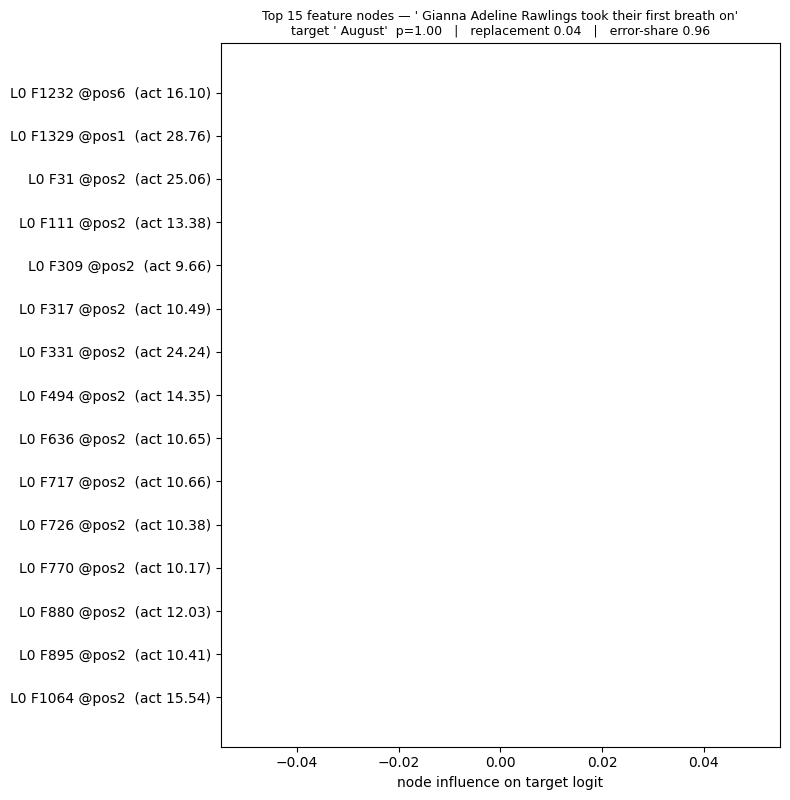

In [7]:
import matplotlib.pyplot as plt
import torch

from circuit_tracer.graph import compute_node_influence

TOP_K = 15

A = graph.adjacency_matrix.cpu()
n_logits   = len(graph.logit_targets)
n_features = len(graph.selected_features)

# logit_weights: weight only the logit nodes (last n_logits), as prune_graph does.
logit_weights = torch.zeros(A.shape[0])
logit_weights[-n_logits:] = graph.logit_probabilities.cpu()
node_influence = compute_node_influence(A, logit_weights)

feat_infl = node_influence[:n_features]
order = torch.argsort(feat_infl, descending=True)[:TOP_K]

labels, vals = [], []
for i in order.tolist():
    layer, pos, fidx = graph.active_features[graph.selected_features[i]].tolist()
    act = graph.activation_values[i].item()
    labels.append(f"L{layer} F{fidx} @pos{pos}  (act {act:.2f})")
    vals.append(feat_infl[i].item())

fig, ax = plt.subplots(figsize=(8, 0.42 * len(labels) + 1.8))
ax.barh(range(len(labels)), vals, color="#3b7dd8")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("node influence on target logit")
ax.set_title(
    f"Top {len(labels)} feature nodes — {report['prompt']!r}\n"
    f"target {report['top_logit_token']!r}  p={report['target_logit_prob']:.2f}   |   "
    f"replacement {report['replacement_score']:.2f}   |   "
    f"error-share {report['error_influence_share']:.2f}",
    fontsize=9,
)
plt.tight_layout()
plt.show()

## 7 · Launch the web viewer  *(one per model)*

Serves circuit-tracer's interactive viewer for the current model's `explore/` folder (in-process). **Each model (`CHOICE`) gets its own port** — `8050 + n_layers`, so L1→8051, L2→8052, L4→8054, L8→8058 — and live servers are tracked in `servers` (keyed by scan). That means you can switch `CHOICE` in cell 1, re-run cells 3–7, and open a **second viewer alongside** the first to compare models side by side; re-running for the *same* model just restarts its viewer. After rebuilding for a new prompt, open the printed `?slug=` link or pick it from the viewer's dropdown. Stop one with `servers['grid-L4-H6'].stop()`, or all with `[s.stop() for s in servers.values()]`.

In [45]:
from clts.serve_ui import start_server

# One viewer PER MODEL, each on its own port, so switching CHOICE and re-running
# spins up a SEPARATE viewer instead of killing the one you already had open for
# another model. Re-running for the same model restarts its viewer (picks up new
# graphs). Live servers are kept in `servers` (scan -> server).
# Port comes from CHOICE (NOT the cached `model`, which may still be a different
# layer if you switched CHOICE without reloading) so it always matches
# GRAPH_DIR/SCAN_NAME and never collides with another model's server.
VIEWER_PORT = 8050 + int(CHOICE[1:])         # L1->8051, L2->8052, L4->8054, L8->8058
features_dir = storage_root() / "clt_features" / SCAN_NAME

servers      = globals().get("servers", {})       # scan -> running server
viewer_ports = globals().get("viewer_ports", {})  # scan -> port
if SCAN_NAME in servers:                           # restart only THIS model's viewer
    servers[SCAN_NAME].stop()
servers[SCAN_NAME] = start_server(str(GRAPH_DIR), str(features_dir), SCAN_NAME, port=VIEWER_PORT)
viewer_ports[SCAN_NAME] = VIEWER_PORT

print(f"Viewer [{CHOICE} · {SCAN_NAME}] → http://localhost:{VIEWER_PORT}/?slug={slug}")
print("That link loads THIS prompt's graph directly.")
print("For another prompt: re-run cell 4 (compute_graph), then open its printed ?slug= link")
print("or switch via the dropdown at the top of the viewer.")
print("\nOpen viewers (one per model): "
      + ", ".join(f"{s}@{viewer_ports[s]}" for s in sorted(servers)))
print("Switch CHOICE (cell 1) + re-run 3→4→7 to open another model's viewer alongside this one.")
print("Stop one:  servers['grid-L4-H6'].stop()   ·   Stop all: [s.stop() for s in servers.values()]")

Viewer [L1 · grid-L1-H6] → http://localhost:8051/?slug=nevaeh-alice-kay-was-born-on-the-memorable-date-of
That link loads THIS prompt's graph directly.
For another prompt: re-run cell 4 (compute_graph), then open its printed ?slug= link
or switch via the dropdown at the top of the viewer.

Open viewers (one per model): grid-L1-H6@8051, grid-L2-H6@8052, grid-L4-H6@8054
Switch CHOICE (cell 1) + re-run 3→4→7 to open another model's viewer alongside this one.
Stop one:  servers['grid-L4-H6'].stop()   ·   Stop all: [s.stop() for s in servers.values()]


## 8 · Feature Explorer — which CLT features recall a birth month

The CLT analog of the SAE "features that fire on token X" sweep. For each month, take people born in that month, build the recall prompt (`…was born on`, template 0), run the model, and read the CLT feature activations **at the recall position** (the last token, where the month is predicted). Aggregate across people to get each feature's mean activation per month, then rank by:

- **`mean_target`** — how hard a feature fires on this month's recall positions, and
- **`specificity = mean_target / mean_other`** — how selectively it fires on this month vs. a shared baseline of all *other* months.

Features are identified as `L{layer} F{idx}` — the same scheme as the attribution chart (cell 6) and the web viewer (cell 7), so a feature you find here can be looked up there. Needs cells 1–3 (reuses the loaded `model`).

### 8a · Sweep — gather recall features per month

Runs `~N_PER_MONTH` people through each of the twelve months and accumulates the per-feature activation sum. Cached to `clt_storage/clt_feature_explorer/<scan>/` — set `RECOMPUTE = True` (or bump `N_PER_MONTH`) to re-run. ~minutes on CPU for the first build; instant once cached.

In [ ]:
import torch
from collections import defaultdict

MONTH_STRINGS = [
    "January", "February", "March",     "April",   "May",      "June",
    "July",    "August",   "September", "October", "November", "December",
]

# In-vocab people grouped by birth month (same name filter cell 4 uses). Order
# follows people.json, so the per-month sample below is deterministic.
# NOTE the LEADING SPACE in the name check — the model saw every bio starting
# " <Name> ...", so without it the condensed tokenizer drops ~97% of people
# (50,000 -> 1,551). Same convention as inference_explorer.ipynb.
people_by_month = defaultdict(list)
for p in sampler.people:
    nm = f" {p['first_name']} {p['last_name']}"
    if name_in_vocab(nm):
        people_by_month[p["birthmonth"]].append(p)

print("in-vocab people per month:")
for m in MONTH_STRINGS:
    print(f"  {m:>10}: {len(people_by_month[m]):>5}")


def recall_prompt(person, exposure_idx=0):
    """Training-prefix prompt ending right before the birth month, so the next
    token the model predicts is the month (template 0 = '<name> was born on')."""
    bio = sampler.render(person, exposure_idx)
    full_date = f"{person['birthmonth']} {person['birthday']}, {person['birthyear']}"
    return bio[:bio.index(full_date)].rstrip()


@torch.no_grad()
def recall_features(prompt):
    """CLT feature activations at the recall position (the last token).

    get_activations returns [n_layers, seq, d_transcoder]; position 0 (BOS) is
    already zeroed by the model. We take the final position — the moment the
    month is recalled. Returns [n_layers, d_transcoder]."""
    _logits, cache = model.get_activations(prompt)
    return cache[:, -1, :].clone()

In [5]:
import time

N_PER_MONTH = 200    # people sampled per month (CPU inference cost scales with this)
RECOMPUTE = False    # set True to ignore the cache and re-run the sweep

CACHE_DIR = storage_root() / "clt_feature_explorer" / SCAN_NAME
CACHE_PATH = CACHE_DIR / f"recall_month_sums_n{N_PER_MONTH}.pt"

if CACHE_PATH.exists() and not RECOMPUTE:
    blob = torch.load(CACHE_PATH, weights_only=False)
    month_sum, month_cnt = blob["sum"], blob["count"]
    print(f"loaded cached sweep from {CACHE_PATH}")
else:
    # Per month: running sum of the [n_layers, d_transcoder] recall-position
    # activation across the sampled people, plus how many people contributed.
    month_sum, month_cnt = {}, {}
    t0 = time.time()
    for m in MONTH_STRINGS:
        people = people_by_month[m][:N_PER_MONTH]
        s = None
        for p in people:
            feats = recall_features(recall_prompt(p))     # [n_layers, d_transcoder]
            s = feats.clone() if s is None else s + feats
        month_sum[m] = s
        month_cnt[m] = len(people)
        print(f"  {m:>10}: {len(people):>4} people  ({time.time() - t0:5.1f}s elapsed)")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    torch.save({"sum": month_sum, "count": month_cnt}, CACHE_PATH)
    print(f"wrote {CACHE_PATH}")

# Totals across all months -> the 'other' baseline for any single month.
total_sum = sum(month_sum[m] for m in MONTH_STRINGS)
total_cnt = sum(month_cnt[m] for m in MONTH_STRINGS)
print(f"\ntotal recall positions swept: {total_cnt:,}  (feature tensor {tuple(total_sum.shape)})")


def month_feature_stats(month):
    """Per-feature mean activation for `month` (target) vs all other months (baseline).
    Both are [n_layers, d_transcoder]."""
    tgt_mean = month_sum[month] / max(month_cnt[month], 1)
    other_mean = (total_sum - month_sum[month]) / max(total_cnt - month_cnt[month], 1)
    return tgt_mean, other_mean


def top_features(tgt_mean, other_mean, k=15, by="mean", min_target=0.0):
    """Rank flattened (layer, feature) entries by mean activation or specificity.
    Returns rows of (layer, feature_idx, mean_target, mean_other, specificity)."""
    spec = tgt_mean / other_mean.clamp_min(1e-6)
    if by == "specificity":
        score = spec.clone()
        score[tgt_mean < min_target] = -float("inf")    # floor near-dead features
    else:
        score = tgt_mean
    order = torch.argsort(score.flatten(), descending=True)[:k]
    rows = []
    for f in order.tolist():
        layer, idx = divmod(f, tgt_mean.shape[1])
        rows.append((layer, idx, float(tgt_mean[layer, idx]),
                     float(other_mean[layer, idx]), float(spec[layer, idx])))
    return rows


def print_rows(rows, title):
    print(title)
    print(f"  {'L.feat':>12}  {'mean_tgt':>9}  {'mean_oth':>9}  {'specif':>8}")
    for layer, idx, mt, mo, sp in rows:
        print(f"  {'L'+str(layer)+' F'+str(idx):>12}  {mt:>9.4f}  {mo:>9.4f}  {sp:>8.2f}")

loaded cached sweep from /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/clt_feature_explorer/grid-L4-H6/recall_month_sums_n200.pt

total recall positions swept: 1,551  (feature tensor (4, 6144))


### 8b · Inspect one month

Pick a `MONTH` and rank its recall features two ways: by raw **mean activation** (how hard they fire on this month) and by **specificity** (`mean_target / mean_other` — how selectively they fire on this month vs. all others). Look any `L{layer} F{idx}` up in the web viewer (cell 7) or the attribution chart (cell 6).

In [9]:
MONTH = "August"     # pick any month from MONTH_STRINGS
K = 100
MIN_TARGET = 0.005   # floor for specificity ranking (drops near-dead features)

tgt_mean, other_mean = month_feature_stats(MONTH)
print(f"=== {MONTH}  (n={month_cnt[MONTH]} people, "
      f"baseline = {total_cnt - month_cnt[MONTH]:,} other-month positions) ===\n")
print_rows(top_features(tgt_mean, other_mean, k=K, by="mean"),
           f"Top {K} features by mean activation:")
print()
print_rows(top_features(tgt_mean, other_mean, k=K, by="specificity", min_target=MIN_TARGET),
           f"Top {K} features by specificity (mean_target >= {MIN_TARGET}):")

=== August  (n=123 people, baseline = 1,428 other-month positions) ===

Top 100 features by mean activation:
        L.feat   mean_tgt   mean_oth    specif
      L3 F4768   103.4093     0.0976   1059.03
      L3 F2427   102.2672    49.4285      2.07
      L2 F5546    60.6490    60.2139      1.01
      L1 F4580    55.3843    55.2895      1.00
      L1 F1455    54.1655    53.9388      1.00
      L2 F3606    51.1904    50.9012      1.01
      L2 F1070    49.5882    49.4088      1.00
      L2 F2197    47.6197    46.9263      1.01
      L3 F1480    44.4875     1.7929     24.81
      L2 F2894    43.8117    43.1400      1.02
      L1 F4009    42.4457    42.3614      1.00
      L3 F3910    42.3053    39.7757      1.06
       L2 F578    36.6836    36.4600      1.01
      L2 F2602    34.6836    34.9616      0.99
      L1 F1335    33.9512    33.8666      1.00
      L3 F1768    30.4494    38.0248      0.80
       L1 F972    29.8563    29.8265      1.00
      L1 F5664    28.3734    28.2448      1.0

### 8c · All months at a glance

The same specificity ranking, one row block per month. The `other` baseline is shared (all positions not in that month), so the specificity numbers are directly comparable across the twelve breakdowns. `MIN_TARGET` floors `mean_target` first — without it, near-dead features with `mean_target ≈ 0` get astronomical specificity ratios and dominate.

In [ ]:
TOP_K = 5
MIN_TARGET = 0.005   # floor mean_target before ranking by specificity

for m in MONTH_STRINGS:
    if month_cnt[m] == 0:
        print(f"\n=== {m}: no people ===")
        continue
    tgt_mean, other_mean = month_feature_stats(m)
    rows = top_features(tgt_mean, other_mean, k=TOP_K, by="specificity", min_target=MIN_TARGET)
    print(f"\n=== {m}  (n={month_cnt[m]}) — top {TOP_K} by specificity ===")
    print(f"  {'L.feat':>12}  {'mean_tgt':>9}  {'mean_oth':>9}  {'specif':>8}")
    for layer, idx, mt, mo, sp in rows:
        print(f"  {'L'+str(layer)+' F'+str(idx):>12}  {mt:>9.4f}  {mo:>9.4f}  {sp:>8.2f}")